# gsMap

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Impor

In [2]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)

sc.settings.figdir = fig_path

In [3]:
sdata = sc.read_h5ad(os.path.join(expr_path, '2025-07-03-finalized-ct-rgn.h5ad'))
sdata

AnnData object with n_obs × n_vars = 538188 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta', 'level_3_label', 'coronal_position_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'leve

### create h5ad for each sample

In [9]:
wt_samples = sdata.obs.loc[sdata.obs['condition'] == 'WT', 'sample_id'].unique()
wt_samples

['sample6', 'sample5', 'sample17', 'sample18', 'sample13', ..., 'sample2', 'sample9', 'sample10', 'sample21', 'sample22']
Length: 12
Categories (24, object): ['sample1', 'sample2', 'sample3', 'sample4', ..., 'sample21', 'sample22', 'sample23', 'sample24']

In [19]:
print(*[f"'{sample}'" for sample in wt_samples])

'sample6' 'sample5' 'sample17' 'sample18' 'sample13' 'sample14' 'sample1' 'sample2' 'sample9' 'sample10' 'sample21' 'sample22'


In [20]:
print(*[f"'scz/ST/2025-10-25-{sample}.h5ad'" for sample in wt_samples])

'scz/ST/2025-10-25-sample6.h5ad' 'scz/ST/2025-10-25-sample5.h5ad' 'scz/ST/2025-10-25-sample17.h5ad' 'scz/ST/2025-10-25-sample18.h5ad' 'scz/ST/2025-10-25-sample13.h5ad' 'scz/ST/2025-10-25-sample14.h5ad' 'scz/ST/2025-10-25-sample1.h5ad' 'scz/ST/2025-10-25-sample2.h5ad' 'scz/ST/2025-10-25-sample9.h5ad' 'scz/ST/2025-10-25-sample10.h5ad' 'scz/ST/2025-10-25-sample21.h5ad' 'scz/ST/2025-10-25-sample22.h5ad'


In [11]:
# batch 
for current_sample in tqdm(wt_samples): 
    # single sample test object
    tdata = sdata[sdata.obs['sample_id'] == current_sample].copy()

    tdata.X = tdata.layers['raw'].copy()
    del tdata.layers['log2_norm1e4']
    del tdata.layers['log2_norm1e4_scaled']
    del tdata.layers['norm1e4']
    tdata.obsp = None

    del tdata.obsm['X_pca_harmony']
    del tdata.obsm['X_pca']
    del tdata.obsm['X_umap']
    tdata.varm = None

    tdata.obs['annotation'] = tdata.obs['level_2'].copy()
    tdata.layers['count'] = tdata.X.copy()

    tdata.write_h5ad(os.path.join(expr_path, 'gsmap', f'2025-10-25-{current_sample}.h5ad'))


  0%|          | 0/12 [00:00<?, ?it/s]

## gsMap

In [ ]:
%%bash

# Define list of samples to process
samples=("sample6" "sample5" "sample17" "sample18" "sample13" "sample2" "sample9" "sample10" "sample21" "sample22")

# Run gsmap for each sample
for sample in "${samples[@]}"; do
    echo "Processing $sample..."
    gsmap quick_mode \
    --workdir './scz_output' \
    --gsMap_resource_dir 'gsMap_resource' \
    --homolog_file 'gsMap_resource/homologs/mouse_human_homologs.txt' \
    --sample_name "$sample" \
    --hdf5_path "scz/ST/2025-10-25-$sample.h5ad" \
    --annotation 'annotation' \
    --data_layer 'count' \
    --sumstats_file 'scz/GWAS/PGC3_SCZ_wave3_public_INFO80.sumstats.gz' \
    --trait_name 'scz' \
    --gM_slices './scz_output/sample_slice_mean.parquet'
    echo "Completed $sample"
done

### gsmap vs. Grin2a

In [4]:
wt_samples = sdata.obs.loc[sdata.obs['condition'] == 'WT', 'sample_id'].unique()
wt_samples

['sample6', 'sample5', 'sample17', 'sample18', 'sample13', ..., 'sample2', 'sample9', 'sample10', 'sample21', 'sample22']
Length: 12
Categories (24, object): ['sample1', 'sample2', 'sample3', 'sample4', ..., 'sample21', 'sample22', 'sample23', 'sample24']

In [5]:
# load gsmap results
gsmap_path = os.path.join(output_path, 'gsmap/scz_output')

res_dfs = []
for sample in tqdm(wt_samples):
    current_df = pd.read_csv(os.path.join(gsmap_path, sample, "spatial_ldsc", f'{sample}_scz.csv.gz'))
    res_dfs.append(current_df)

res_df = pd.concat(res_dfs)
res_df.index = res_df['spot']
res_df = res_df.drop(columns=['spot'])
res_df['gsmap_score'] = -np.log10(res_df['p'])
res_df

  0%|          | 0/12 [00:00<?, ?it/s]

,beta,se,z,p,gsmap_score
spot,,,,,
sample6_Position231_1,2.278895e-08,8.757213e-09,2.602307,0.004630,2.334424
sample6_Position231_2,1.916237e-08,8.597132e-09,2.228925,0.012909,1.889093
sample6_Position231_3,3.298691e-08,7.830847e-09,4.212432,0.000013,4.898535
sample6_Position231_4,2.458607e-08,1.057190e-08,2.325605,0.010020,1.999141
sample6_Position231_5,2.879632e-08,8.331501e-09,3.456319,0.000274,3.562561
...,...,...,...,...,...
sample22_Position343_143,3.310460e-08,7.958920e-09,4.159433,0.000016,4.797188
sample22_Position343_144,1.906568e-08,9.564769e-09,1.993324,0.023113,1.636144
sample22_Position343_145,3.174305e-08,9.234207e-09,3.437550,0.000294,3.532389


In [15]:
sdata.obs = pd.merge(sdata.obs, res_df, left_index=True, right_index=True, how='left')
sdata.obs

,sample,fov_id,volume,fov_x,fov_y,seg_label,global_x,global_y,sample_id,condition,...,beta_y,se_y,z_y,p_y,gsmap_score_y,beta,se,z,p,gsmap_score
unique_index,,,,,,,,,,,,,,,,,,,,,
sample8_Position688_1,sample8,Position688,9514,1823,1116,1,1823,2969,sample8,HET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample8_Position688_2,sample8,Position688,9109,132,173,2,132,2026,sample8,HET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample8_Position688_3,sample8,Position688,5644,1298,712,3,1298,2565,sample8,HET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample8_Position688_5,sample8,Position688,6673,1287,1491,5,1287,3344,sample8,HET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample8_Position688_6,sample8,Position688,12560,731,1370,6,731,3223,sample8,HET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample22_Position343_143,sample22,Position343,10444,868,888,143,26717,10169,sample22,WT,...,3.310460e-08,7.958920e-09,4.159433,0.000016,4.797188,3.310460e-08,7.958920e-09,4.159433,0.000016,4.797188
sample22_Position343_144,sample22,Position343,4450,1049,1803,144,26898,11084,sample22,WT,...,1.906568e-08,9.564769e-09,1.993324,0.023113,1.636144,1.906568e-08,9.564769e-09,1.993324,0.023113,1.636144
sample22_Position343_145,sample22,Position343,8310,1074,463,145,26923,9744,sample22,WT,...,3.174305e-08,9.234207e-09,3.437550,0.000294,3.532389,3.174305e-08,9.234207e-09,3.437550,0.000294,3.532389


In [19]:
het_neuron = sdata[(sdata.obs['genotype'] == 'HET') & (sdata.obs['level_1'] == 'Neuron')]
het_neuron


View of AnnData object with n_obs × n_vars = 129003 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta', 'level_3_label', 'coronal_position_label', 'beta_x', 'se_x', 'z_x', 'p_x', 'gsmap_score_x', 'beta_y', 'se_y', 'z_y', 'p_y', 'gsmap_score_y', 'beta', 'se', 'z', 'p', 'gsmap_score'
    var: 'highly_variable', 'mean', 'st

In [16]:
wt_neuron = sdata[(sdata.obs['genotype'] == 'WT') & (sdata.obs['level_1'] == 'Neuron')]
wt_neuron


View of AnnData object with n_obs × n_vars = 131691 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta', 'level_3_label', 'coronal_position_label', 'beta_x', 'se_x', 'z_x', 'p_x', 'gsmap_score_x', 'beta_y', 'se_y', 'z_y', 'p_y', 'gsmap_score_y', 'beta', 'se', 'z', 'p', 'gsmap_score'
    var: 'highly_variable', 'mean', 'st

In [12]:
current_protocol = 'RIBO'
input_path = os.path.join(expr_path, 'DE analysis')
basal_grin2a_dict = pd.read_excel(os.path.join(input_path, '2025-04-17_basal_Grin2a.xlsx'), sheet_name=None)
grin2a_df = basal_grin2a_dict[current_protocol]
grin2a_df['level_3_label'] = grin2a_df['cell_type'].str.split('-').str[0]
grin2a_df['level_3_label'] = grin2a_df['level_3_label'].str.replace('/', '_')
grin2a_df['level_3_label'] = grin2a_df['level_3_label'].astype('category')
grin2a_df['level_3_label'].unique()
grin2a_df = grin2a_df.loc[:, ['level_3_label', 'Grin2a_expression']]
grin2a_df

,level_3_label,Grin2a_expression
0,TEGLU_L2_3,1.162185
1,TEGLU_L4_5,0.971603
2,TEGLU_L5_6,0.842755
3,TEGLU_L6,0.850652
4,TEGLU_CA,1.672495
5,TEGLU_Mix,0.301487
6,DGGRC,0.843257
7,TEINH_1,0.597353
8,TEINH_2,0.642172
9,TEINH_3,0.838104


In [10]:
wt_neuron[wt_neuron.obs['protocol'] == 'STAR'].obs.groupby('level_3_label')['gsmap_score'].mean()

level_3_label
DEGLU         2.595356
DGGRC         2.539509
HABCHO        2.195281
MSN_1         2.814109
MSN_2         2.829506
PEP           2.905842
TEGLU_CA      2.882548
TEGLU_L2_3    3.462431
TEGLU_L4_5    3.261467
TEGLU_L5_6    3.348722
TEGLU_L6      3.294798
TEGLU_Mix     3.200458
TEINH_1       2.947935
TEINH_2       3.144530
TEINH_3       3.205301
TEINH_4       3.208570
Name: gsmap_score, dtype: float64

In [11]:
score_df = pd.DataFrame(wt_neuron.obs.groupby('level_3_label')['gsmap_score'].mean())
score_df['STAR_score'] = wt_neuron[wt_neuron.obs['protocol'] == 'STAR'].obs.groupby('level_3_label')['gsmap_score'].mean()
score_df['RIBO_score'] = wt_neuron[wt_neuron.obs['protocol'] == 'RIBO'].obs.groupby('level_3_label')['gsmap_score'].mean()
score_df

,gsmap_score,STAR_score,RIBO_score
level_3_label,,,
DEGLU,2.763183,2.595356,2.958485
DGGRC,2.626041,2.539509,2.691406
HABCHO,2.353612,2.195281,2.495326
MSN_1,2.990656,2.814109,3.185681
MSN_2,2.988056,2.829506,3.168644
PEP,2.916587,2.905842,2.927041
TEGLU_CA,3.148682,2.882548,3.386204
TEGLU_L2_3,3.711269,3.462431,3.997260
TEGLU_L4_5,3.571482,3.261467,3.885725


In [12]:
test_df = pd.merge(grin2a_df, score_df, left_on='level_3_label', right_index=True, how='left')
test_df = test_df.loc[test_df['level_3_label'] != 'TEGLU_Mix']
test_df = test_df.sort_values(by='Grin2a_expression', ascending=True)
test_df = test_df.reset_index(drop=True)
test_df['rank'] = test_df.index + 1

star_df = test_df.loc[:, ['level_3_label', 'Grin2a_expression', 'STAR_score', 'rank']]
star_df.columns = ['level_3_label', 'Grin2a_expression', 'gsmap_score', 'rank']
star_df['protocol'] = 'STAR'

ribo_df = test_df.loc[:, ['level_3_label', 'Grin2a_expression', 'RIBO_score', 'rank']]
ribo_df.columns = ['level_3_label', 'Grin2a_expression', 'gsmap_score', 'rank']
ribo_df['protocol'] = 'RIBO'

temp_df = pd.concat([star_df, ribo_df])
temp_df

,level_3_label,Grin2a_expression,gsmap_score,rank,protocol
0,PEP,0.351916,2.905842,1,STAR
1,TEINH_4,0.418524,3.208570,2,STAR
2,HABCHO,0.430511,2.195281,3,STAR
3,MSN_2,0.532247,2.829506,4,STAR
4,DEGLU,0.591046,2.595356,5,STAR
5,TEINH_1,0.597353,2.947935,6,STAR
6,TEINH_2,0.642172,3.144530,7,STAR
7,MSN_1,0.680843,2.814109,8,STAR
8,TEINH_3,0.838104,3.205301,9,STAR
9,TEGLU_L5_6,0.842755,3.348722,10,STAR


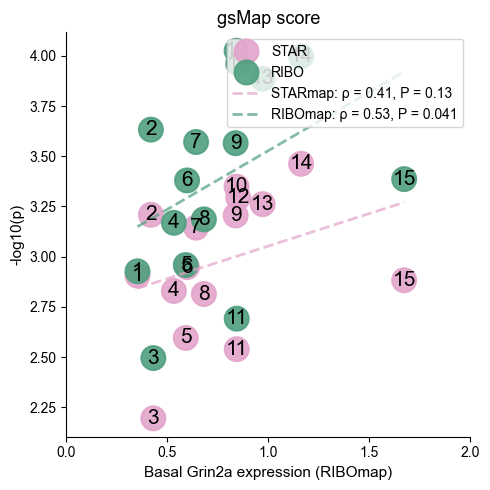

In [60]:
# --- PLOT ---
from scipy.stats import linregress, spearmanr
metric_of_interest = 'gsmap_score'
plt.figure(figsize=(5, 5))
ax = sns.scatterplot(
    data=temp_df,
    x='Grin2a_expression',
    y=metric_of_interest,
    hue='protocol',
    palette={'STAR': '#e3a4ca', 'RIBO': '#509f80'},
    s=300,
    edgecolor=None,
    alpha=0.9
)

# Add regression lines per protocol
for protocol, color in zip(['STAR', 'RIBO'], ['#e3a4ca', '#509f80']):
    subset = temp_df[temp_df['protocol'] == protocol]
    if subset.shape[0] < 3:
        continue

    rho, pval = spearmanr(subset['Grin2a_expression'], subset[metric_of_interest])
    slope, intercept, *_ = linregress(subset['Grin2a_expression'], subset[metric_of_interest])
    x_vals = [subset['Grin2a_expression'].min(), subset['Grin2a_expression'].max()]
    x_vals
    y_vals = [slope * x + intercept for x in x_vals]

    ax.plot(x_vals, y_vals, linestyle='--', color=color, linewidth=2,
            label=f"{protocol}map: ρ = {rho:.2f}, P = {pval:.2g}", alpha=0.7)

# loop through each x,y pair
for _, row in temp_df.iterrows():
    ax.annotate(row['rank'],  xy=(row['Grin2a_expression'], row[metric_of_interest],), 
                color='k', 
                fontsize=15, weight='medium',
                horizontalalignment='center',
                verticalalignment='center')
    
# Formatting
ax.set_title(f"gsMap score", fontsize=13)
ax.set_xlabel("Basal Grin2a expression (RIBOmap)", fontsize=11)
ax.set_ylabel("-log10(p)", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 2)
ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])

plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(fig_path,f'gsmap_basal_scatter.pdf'), format='pdf', dpi=300)
plt.show()


### gsmap vs. LogFC

In [13]:
ctype_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 'DGGRC', 'HABCHO', 
              'MSN_1', 'MSN_2', 'DEGLU', 'PEP', 'TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4']
# logfc_df = grin2a_df.loc[grin2a_df['level_3_label'].isin(ctype_list), :].copy()
# logfc_df

In [14]:
# Load all sheets from the Excel file into a dictionary
l3_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_3_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l3_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l3_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

In [11]:
# export as editable fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

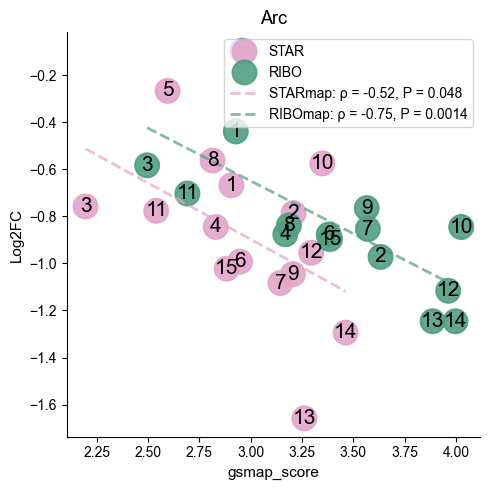

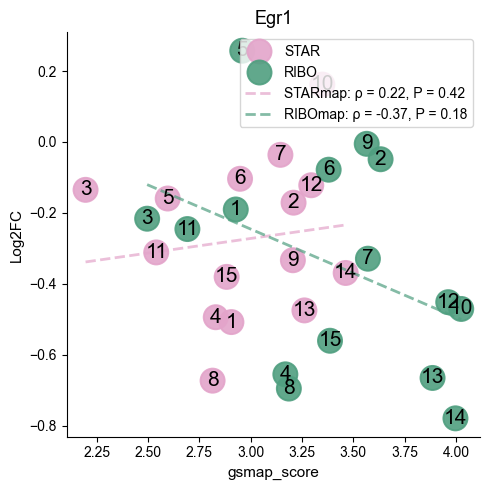

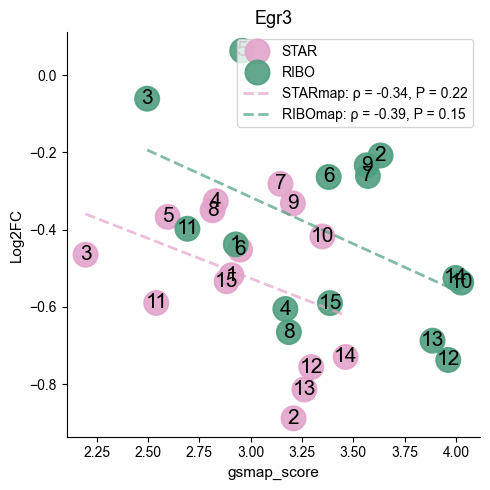

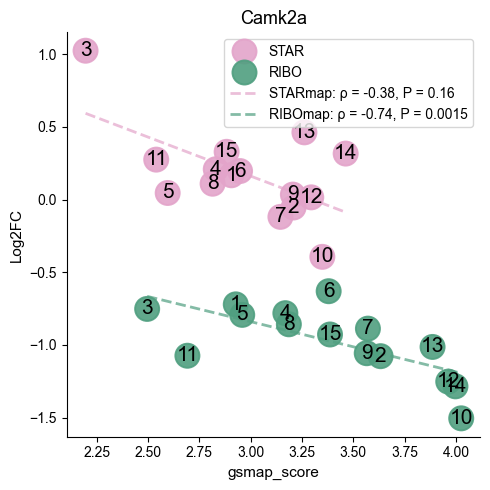

In [16]:
# for gene_of_interest in genes_to_label:
from scipy.stats import linregress, spearmanr
for gene_of_interest in ['Arc', 'Egr1', 'Egr3', 'Camk2a']:
    protocols = ['STAR', 'RIBO']
    metric_of_interest = 'logfoldchanges'  # or whatever metric you're using
    current_df = grin2a_df.loc[grin2a_df['level_3_label'].isin(ctype_list), :].copy()
    current_df = pd.merge(current_df, score_df, left_on='level_3_label', right_index=True, how='left')
    merged_all = []

    # Loop over protocols and collect data
    for protocol in protocols:
        lfc_per_cell_type = {}

        for cell_type in current_df['level_3_label'].tolist():
            prefix = cell_type.replace("/", "_").split("-")[0]
            key = f"{prefix}_{protocol}"

            df = l3_deg_combined_dict.get(key)
            if df is None or gene_of_interest not in df['names'].values:
                continue

            lfc = df.loc[df['names'] == gene_of_interest, metric_of_interest]
            lfc_per_cell_type[cell_type] = lfc.values[0]

        # Construct DataFrame and merge
        lfc_df = pd.DataFrame(list(lfc_per_cell_type.items()), columns=['level_3_label', metric_of_interest])
        merged_df = pd.merge(current_df, lfc_df, on='level_3_label', how='inner')
        merged_df['level_3_label'] = merged_df['level_3_label'].str.split('-').str[0]
        merged_df = merged_df[merged_df['level_3_label'] != 'TEGLU_Mix']
        merged_df['protocol'] = protocol
        merged_df = merged_df.loc[:, ['level_3_label', 'Grin2a_expression', metric_of_interest, 'protocol', f"{protocol}_score"]]
        merged_df.columns = ['level_3_label', 'Grin2a_expression', metric_of_interest, 'protocol', "gsmap_score"]
        merged_df = merged_df.sort_values(by='Grin2a_expression', ascending=True)
        merged_df = merged_df.reset_index(drop=True)
        merged_df['rank'] = merged_df.index + 1
        merged_all.append(merged_df)

    # Combine STAR + RIBO
    merged_all_df = pd.concat(merged_all)

    # --- PLOT ---
    plt.figure(figsize=(5, 5))
    ax = sns.scatterplot(
        data=merged_all_df,
        x='gsmap_score',
        y=metric_of_interest,
        hue='protocol',
        palette={'STAR': '#e3a4ca', 'RIBO': '#509f80'},
        s=300,
        edgecolor=None,
        alpha=0.9
    )

    # Add regression lines per protocol
    for protocol, color in zip(['STAR', 'RIBO'], ['#e3a4ca', '#509f80']):
        subset = merged_all_df[merged_all_df['protocol'] == protocol]
        if subset.shape[0] < 3:
            continue

        rho, pval = spearmanr(subset['gsmap_score'], subset[metric_of_interest])
        slope, intercept, *_ = linregress(subset['gsmap_score'], subset[metric_of_interest])
        x_vals = [subset['gsmap_score'].min(), subset['gsmap_score'].max()]
        x_vals
        y_vals = [slope * x + intercept for x in x_vals]

        ax.plot(x_vals, y_vals, linestyle='--', color=color, linewidth=2,
                label=f"{protocol}map: ρ = {rho:.2f}, P = {pval:.2g}", alpha=0.7)

    # loop through each x,y pair
    for _, row in merged_all_df.iterrows():
        ax.annotate(row['rank'],  xy=(row['gsmap_score'], row[metric_of_interest],), 
                    color='k', 
                    fontsize=15, weight='medium',
                    horizontalalignment='center',
                    verticalalignment='center')
        
    # Formatting
    ax.set_title(f"{gene_of_interest}", fontsize=13)
    ax.set_xlabel("gsmap_score", fontsize=11)
    ax.set_ylabel("Log2FC", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xlim(0, 2)
    # ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])

    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(fig_path,f'{gene_of_interest}_gsmap_scatter.pdf'), format='pdf', dpi=300)
    plt.show()
